Dataset cargado: 182,938 filas | 33 columnas
Ciudades: ['barcelona', 'euskadi', 'girona', 'madrid', 'malaga', 'mallorca', 'menorca', 'sevilla', 'valencia']
XGBoost version: 3.2.0
Dataset para modelado: 144,865 filas
Features: 17

--- Ocupación por ciudad ---
             count   mean    std  min    25%    50%    75%    max
ciudad                                                           
barcelona  22339.0  0.339  0.262  0.0  0.082  0.329  0.625  0.699
euskadi    10087.0  0.227  0.223  0.0  0.049  0.148  0.345  0.699
girona     14843.0  0.115  0.151  0.0  0.016  0.055  0.148  0.699
madrid     30739.0  0.329  0.264  0.0  0.082  0.268  0.641  0.699
malaga     14865.0  0.239  0.239  0.0  0.033  0.148  0.395  0.699
mallorca   21499.0  0.171  0.188  0.0  0.033  0.099  0.247  0.699
menorca     5374.0  0.153  0.156  0.0  0.033  0.110  0.219  0.699
sevilla    12933.0  0.292  0.254  0.0  0.049  0.214  0.526  0.699
valencia   12186.0  0.296  0.255  0.0  0.060  0.219  0.526  0.699

Ciudades codif

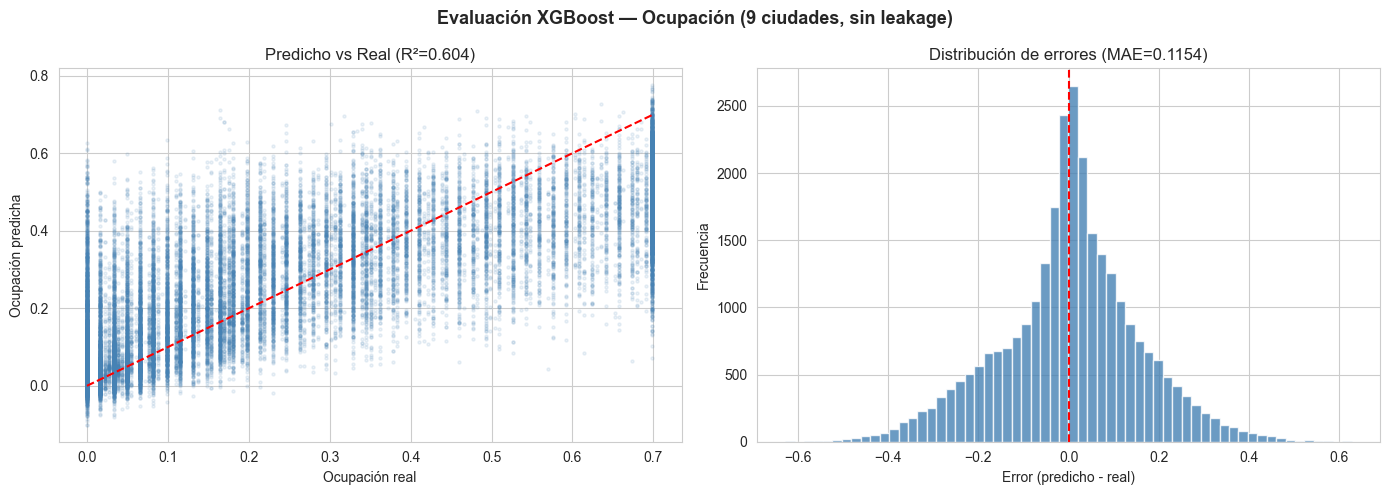

=== IMPORTANCIA DE VARIABLES ===
                  feature  importancia
        host_is_superhost     0.454489
               ciudad_enc     0.081390
   review_scores_location     0.075594
review_scores_cleanliness     0.056433
      review_scores_value     0.054257
           minimum_nights     0.043287
     review_scores_rating     0.039652
                     beds     0.034151
                    price     0.027109
                 room_enc     0.026552
      host_listings_count     0.023067
         instant_bookable     0.019584
         availability_365     0.016224
               barrio_enc     0.014586
                 bedrooms     0.013524
             accommodates     0.011580
                bathrooms     0.008519


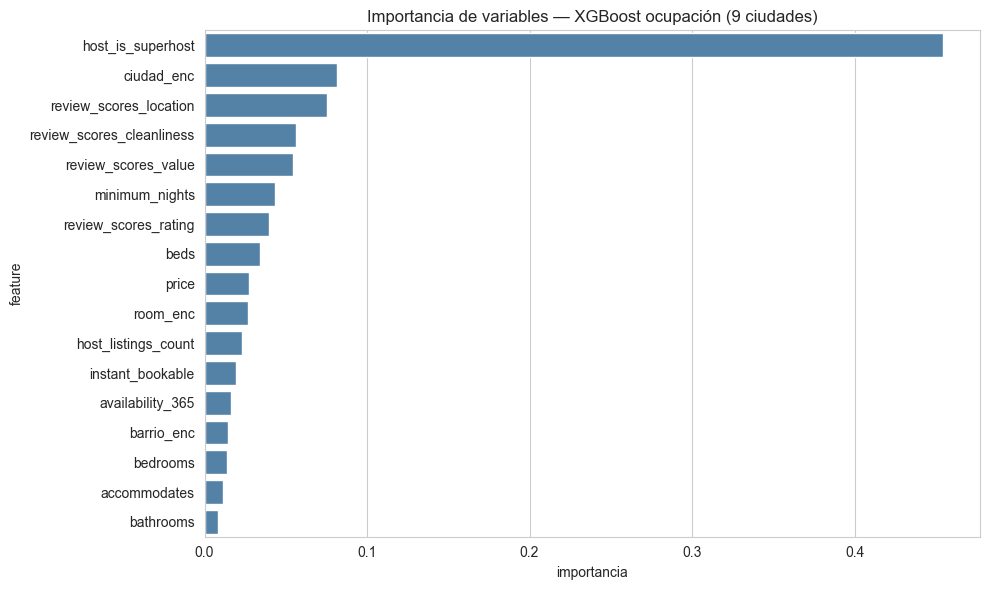

✅ Modelo guardado: /Users/ivannavarrosuero/tfm_vut/src/models/xgboost_ocupacion.pkl
✅ Encoders guardados: /Users/ivannavarrosuero/tfm_vut/src/models/encoders_ocupacion.pkl
✅ Métricas guardadas: /Users/ivannavarrosuero/tfm_vut/src/models/metricas_xgboost_ocupacion.pkl
   xgboost_ocupacion.pkl: 2293.5 KB
   encoders_ocupacion.pkl: 13.3 KB
   metricas_xgboost_ocupacion.pkl: 0.3 KB


In [1]:
# %%
# ============================================================
# CELDA 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
MODELS    = os.path.join(BASE, 'src', 'models')
os.makedirs(MODELS, exist_ok=True)

df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Ciudades: {sorted(df['ciudad'].unique())}")
print(f"XGBoost version: {xgb.__version__}")

# %%
# ============================================================
# CELDA 2 — Preparación de features (sin leakage desde el inicio)
# ============================================================

# Variables de reseñas EXCLUIDAS por data leakage:
# number_of_reviews, number_of_reviews_ltm, reviews_per_month
# estiman indirectamente la ocupación (Modelo San Francisco)

FEATURES_LIMPIAS = [
    'ciudad', 'neighbourhood_cleansed', 'room_type',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'price', 'minimum_nights', 'availability_365',
    'host_is_superhost', 'host_listings_count',
    'instant_bookable',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
]

TARGET = 'ocupacion'

df_model = df[FEATURES_LIMPIAS + [TARGET]].dropna().copy()
print(f"Dataset para modelado: {len(df_model):,} filas")
print(f"Features: {len(FEATURES_LIMPIAS)}")
print(f"\n--- Ocupación por ciudad ---")
print(df_model.groupby('ciudad')[TARGET].describe().round(3))

# Codificamos variables categóricas
le_ciudad = LabelEncoder()
le_barrio = LabelEncoder()
le_room   = LabelEncoder()

df_model['ciudad_enc'] = le_ciudad.fit_transform(df_model['ciudad'])
df_model['barrio_enc'] = le_barrio.fit_transform(df_model['neighbourhood_cleansed'])
df_model['room_enc']   = le_room.fit_transform(df_model['room_type'])

print(f"\nCiudades codificadas: {dict(zip(le_ciudad.classes_, le_ciudad.transform(le_ciudad.classes_)))}")
print(f"Tipos de alojamiento: {dict(zip(le_room.classes_, le_room.transform(le_room.classes_)))}")

FEATURES_NUM = [
    'ciudad_enc', 'barrio_enc', 'room_enc',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'price', 'minimum_nights', 'availability_365',
    'host_is_superhost', 'host_listings_count',
    'instant_bookable',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
]

X = df_model[FEATURES_NUM]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Ocupación media train: {y_train.mean():.3f}")
print(f"Ocupación media test:  {y_test.mean():.3f}")

# %%
# ============================================================
# CELDA 3 — Entrenamiento XGBoost
# ============================================================

modelo_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='mae'
)

modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ Modelo entrenado correctamente")
print(f"Mejor iteración: {modelo_xgb.best_iteration}")

# %%
# ============================================================
# CELDA 4 — Evaluación del modelo
# ============================================================

y_pred = modelo_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN — XGBoost Ocupación (9 ciudades) ===")
print(f"MAE  (Error Absoluto Medio):  {mae:.4f}  ({mae*100:.2f} puntos porcentuales)")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.4f}")
print(f"R²   (Varianza explicada):    {r2:.4f}  ({r2*100:.1f}%)")

# Evaluación por ciudad
print(f"\n--- MAE por ciudad ---")
df_eval = X_test.copy()
df_eval['y_real'] = y_test.values
df_eval['y_pred'] = y_pred
df_eval['ciudad'] = le_ciudad.inverse_transform(df_eval['ciudad_enc'])
df_eval['error_abs'] = abs(df_eval['y_real'] - df_eval['y_pred'])
print(df_eval.groupby('ciudad')['error_abs'].mean().round(4).sort_values())

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 0.7], [0, 0.7], 'r--', linewidth=1.5)
axes[0].set_xlabel('Ocupación real')
axes[0].set_ylabel('Ocupación predicha')
axes[0].set_title(f'Predicho vs Real (R²={r2:.3f})')

errores = y_pred - y_test
axes[1].hist(errores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (predicho - real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de errores (MAE={mae:.4f})')

plt.suptitle('Evaluación XGBoost — Ocupación (9 ciudades, sin leakage)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'xgboost_evaluacion.png'), dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# CELDA 5 — Importancia de variables (SHAP preliminar)
# ============================================================

importancias = pd.DataFrame({
    'feature': FEATURES_NUM,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False)

print("=== IMPORTANCIA DE VARIABLES ===")
print(importancias.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='importancia', y='feature', color='steelblue')
plt.title('Importancia de variables — XGBoost ocupación (9 ciudades)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'xgboost_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()

# %%
# ============================================================
# CELDA 6 — Guardado del modelo y encoders
# ============================================================

# Modelo
ruta_modelo = os.path.join(MODELS, 'xgboost_ocupacion.pkl')
with open(ruta_modelo, 'wb') as f:
    pickle.dump(modelo_xgb, f)

# Encoders
ruta_encoders = os.path.join(MODELS, 'encoders_ocupacion.pkl')
encoders = {
    'le_ciudad': le_ciudad,
    'le_barrio': le_barrio,
    'le_room':   le_room,
    'features':  FEATURES_NUM,
    'ciudades':  list(le_ciudad.classes_),
}
with open(ruta_encoders, 'wb') as f:
    pickle.dump(encoders, f)

# Métricas
metricas = {
    'mae':     mae,
    'rmse':    rmse,
    'r2':      r2,
    'n_train': len(X_train),
    'n_test':  len(X_test),
    'ciudades': list(le_ciudad.classes_),
}
ruta_metricas = os.path.join(MODELS, 'metricas_xgboost_ocupacion.pkl')
with open(ruta_metricas, 'wb') as f:
    pickle.dump(metricas, f)

print("✅ Modelo guardado:", ruta_modelo)
print("✅ Encoders guardados:", ruta_encoders)
print("✅ Métricas guardadas:", ruta_metricas)

for ruta in [ruta_modelo, ruta_encoders, ruta_metricas]:
    tam = os.path.getsize(ruta) / 1024
    print(f"   {os.path.basename(ruta)}: {tam:.1f} KB")